# 🚴‍♂️ Strava Performance & Training Dashboard

Analyse your Strava data — **training trends** and **performance & efforts** — with data pulled
live from a **Strava MCP (Model Context Protocol) server**.

This notebook is an **MCP client**: it launches a Strava MCP server, discovers its tools, and pulls
the results into pandas for analysis. By default it talks to the **bundled mock server**
(`mock_strava_mcp_server.py`) so the dashboard runs end-to-end with realistic synthetic data and no
credentials. To analyse *your* data, point it at a real server (see §2).

**Sections**
1. Setup
2. Connect to the Strava MCP server
3. Fetch activities
4. At a glance (KPIs)
5. Training trends
6. Performance & efforts
7. Drill into a single activity (streams)
8. Key takeaways


## 1. Setup
Imports, plotting style, and helpers.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

%matplotlib inline

# Make the local helper modules importable regardless of how Jupyter was started.
sys.path.insert(0, os.getcwd())
load_dotenv()  # picks up STRAVA_* vars / STRAVA_MCP_COMMAND from a .env file

from strava_mcp_client import StravaMCPClient, add_derived_columns

plt.rcParams.update({
    "figure.figsize": (12, 4.5), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "font.size": 11,
})
STRAVA_ORANGE = "#fc4c02"
COLORS = {"Ride": STRAVA_ORANGE, "Run": "#1f77b4", "Other": "#7f7f7f"}
def color_for(t): return COLORS.get(t, COLORS["Other"])

def fmt_hms(seconds):
    seconds = int(seconds or 0)
    h, rem = divmod(seconds, 3600); m, s = divmod(rem, 60)
    return f"{h}h {m:02d}m" if h else f"{m}m {s:02d}s"

def fmt_pace(min_per_km):
    if pd.isna(min_per_km): return "—"
    m = int(min_per_km); s = int(round((min_per_km - m) * 60))
    if s == 60: m, s = m + 1, 0
    return f"{m}:{s:02d}/km"

print("✅ Setup complete.")

✅ Setup complete.


## 2. Connect to the Strava MCP server

The client launches the configured MCP server over **stdio** and lists the tools it advertises.

**To use your own Strava data**, set the `STRAVA_MCP_COMMAND` environment variable (e.g. in a `.env`
file) to a real Strava MCP server and provide your credentials, for example:

```bash
STRAVA_MCP_COMMAND="npx -y @r-huijts/strava-mcp-server"
STRAVA_CLIENT_ID=...
STRAVA_CLIENT_SECRET=...
STRAVA_ACCESS_TOKEN=...
STRAVA_REFRESH_TOKEN=...
```

With nothing set, the bundled mock server is used (synthetic but realistic data).

In [2]:
client = StravaMCPClient(verbose=True)
tools = client.list_tools()
print("\n🛠️  Tools advertised by this server:")
for t in tools:
    print("   •", t)
client.verbose = False  # quieten subsequent tool calls

🔌 Strava MCP server: bundled mock (mock_strava_mcp_server.py)
   (set STRAVA_MCP_COMMAND to point at a live server, e.g. 'npx -y @r-huijts/strava-mcp-server')



🛠️  Tools advertised by this server:
   • get_recent_activities
   • get_activity_streams
   • get_athlete_stats
   • get_athlete_zones


## 3. Fetch activities
Pull the activity history and add derived columns (km, pace, speed, week/month, etc.).

In [3]:
df = add_derived_columns(client.fetch_activities(limit=2000))
assert not df.empty, "No activities returned by the MCP server."

print(f"📦 {len(df)} activities  |  {df['date'].min()} → {df['date'].max()}")
print("   Types:", dict(df["type"].value_counts()))
preview = df[["start_date", "name", "type", "distance_km", "moving_minutes",
              "elevation_gain_m", "average_hr", "average_watts"]].tail(8).copy()
_num = preview.select_dtypes("number").columns
preview[_num] = preview[_num].round(1)
preview

📦 259 activities  |  2025-02-07 → 2026-06-02
   Types: {'Ride': np.int64(166), 'Run': np.int64(93)}


,start_date,name,type,distance_km,moving_minutes,elevation_gain_m,average_hr,average_watts
251,2026-05-23 10:17:00+00:00,Morning Ride,Ride,31.8,68.0,517.3,149.4,207.7
252,2026-05-24 14:36:00+00:00,Easy Run,Run,15.0,81.5,136.6,157.1,NaN
253,2026-05-25 17:15:00+00:00,Hill Repeats,Ride,18.8,33.0,186.0,149.9,226.2
254,2026-05-27 19:27:00+00:00,Interval Session,Run,9.6,48.5,85.0,166.5,NaN
255,2026-05-30 14:51:00+00:00,Morning Run,Run,14.7,83.1,134.1,159.2,NaN
256,2026-05-31 10:03:00+00:00,Lunch Ride,Ride,40.3,89.0,753.7,139.4,214.1
257,2026-06-01 07:13:00+00:00,Long Run,Run,6.0,28.4,56.7,166.1,NaN
258,2026-06-02 19:54:00+00:00,Parkrun,Run,8.2,38.6,82.0,168.7,NaN


## 4. At a glance
Headline totals by activity type.

In [4]:
summary = df.groupby("type").agg(
    activities=("id", "count"),
    distance_km=("distance_km", "sum"),
    moving_hours=("moving_hours", "sum"),
    elevation_m=("elevation_gain_m", "sum"),
    avg_hr=("average_hr", "mean"),
    avg_speed_kmh=("speed_kmh", "mean"),
).round(1)
summary.loc["TOTAL"] = [
    summary["activities"].sum(), summary["distance_km"].sum(),
    summary["moving_hours"].sum(), summary["elevation_m"].sum(),
    round(df["average_hr"].mean(), 1), round(df["speed_kmh"].mean(), 1),
]
weeks = max((df["start_date"].max() - df["start_date"].min()).days / 7, 1)
print(f"Span: {weeks:.0f} weeks   •   Total moving time: {fmt_hms(df['moving_time_s'].sum())}")
print(f"Avg activities/week: {len(df)/weeks:.1f}   •   Avg distance/week: {df['distance_km'].sum()/weeks:.1f} km")
summary

Span: 69 weeks   •   Total moving time: 249h 05m
Avg activities/week: 3.8   •   Avg distance/week: 84.0 km


,activities,distance_km,moving_hours,elevation_m,avg_hr,avg_speed_kmh
type,,,,,,
Ride,166.0,4936.4,172.8,53268.1,148.2,29.2
Run,93.0,824.9,76.3,6518.8,163.8,11.0
TOTAL,259.0,5761.3,249.1,59786.9,153.8,22.7


## 5. Training trends
How volume (distance, time, elevation) and consistency evolve over time.

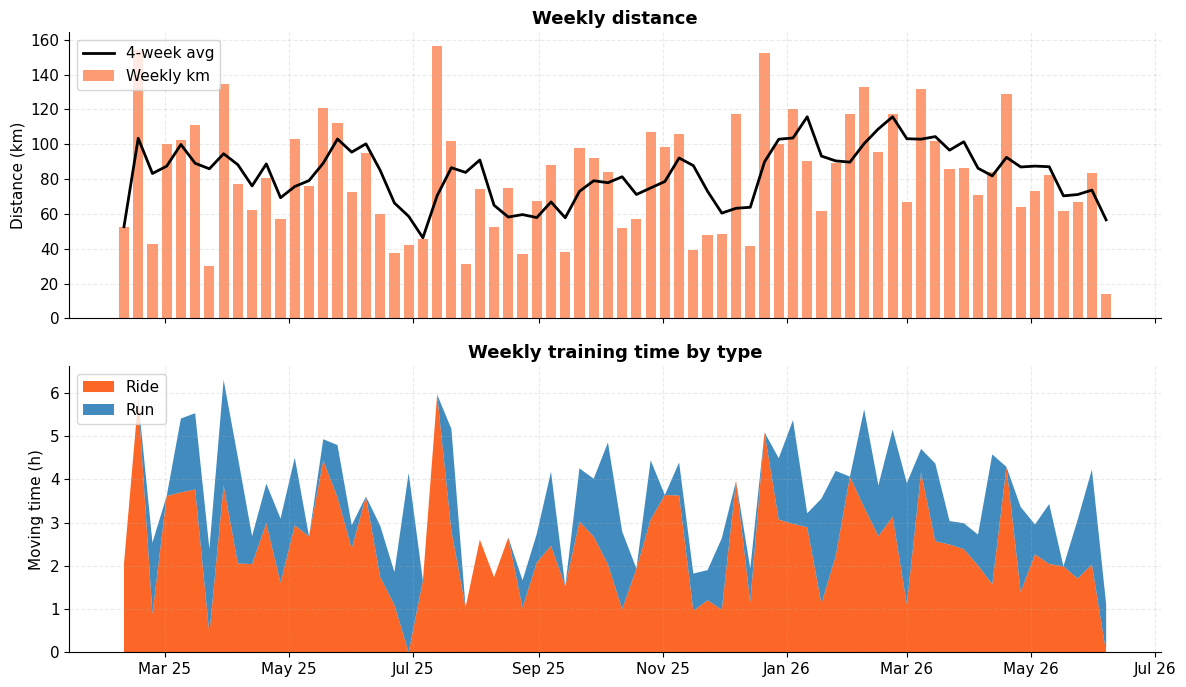

In [5]:
# --- Weekly distance with a 4-week rolling average ---
ts = df.set_index("start_date").sort_index()
weekly_km = ts["distance_km"].resample("W").sum()
weekly_hrs = ts["moving_hours"].resample("W").sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(weekly_km.index, weekly_km.values, width=5, color=STRAVA_ORANGE, alpha=0.55, label="Weekly km")
axes[0].plot(weekly_km.index, weekly_km.rolling(4, min_periods=1).mean(), color="black", lw=2, label="4-week avg")
axes[0].set_ylabel("Distance (km)"); axes[0].set_title("Weekly distance"); axes[0].legend(loc="upper left")

# Weekly moving time split by activity type (stacked area).
wk_type = ts.groupby("type")["moving_hours"].resample("W").sum().unstack(0).fillna(0)
axes[1].stackplot(wk_type.index, *[wk_type[c] for c in wk_type.columns],
                  labels=list(wk_type.columns), colors=[color_for(c) for c in wk_type.columns], alpha=0.85)
axes[1].set_ylabel("Moving time (h)"); axes[1].set_title("Weekly training time by type"); axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.tight_layout(); plt.show()

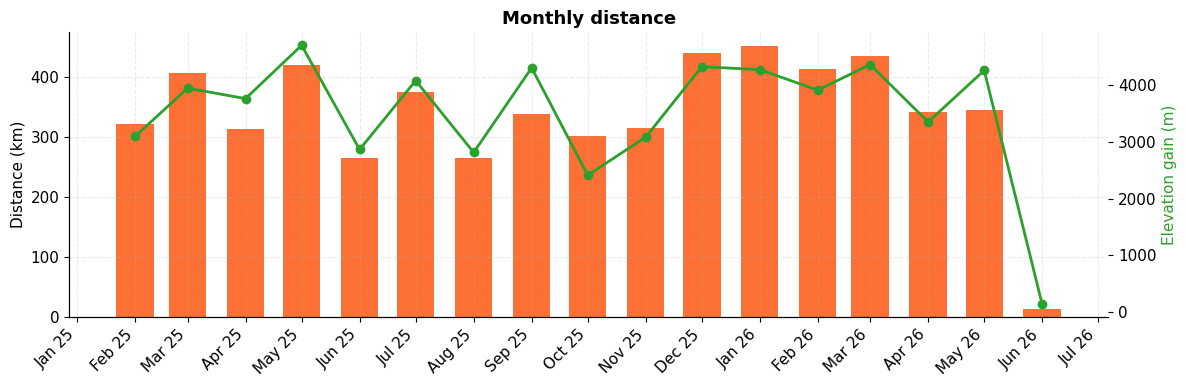

,distance_km,moving_hours,elevation_m,activities
start_date,,,,
2025-07-01 00:00:00+00:00,375.6,15.2,4086.4,18
2025-08-01 00:00:00+00:00,265.7,10.0,2817.9,16
2025-09-01 00:00:00+00:00,338.7,14.8,4312.6,17
2025-10-01 00:00:00+00:00,302.1,14.1,2416.8,17
2025-11-01 00:00:00+00:00,315.5,13.5,3088.8,12
2025-12-01 00:00:00+00:00,439.1,16.7,4331.9,15
2026-01-01 00:00:00+00:00,451.5,19.2,4280.0,18
2026-02-01 00:00:00+00:00,412.7,18.5,3917.8,19
2026-03-01 00:00:00+00:00,435.2,16.1,4369.7,17


In [6]:
# --- Monthly totals ---
monthly = ts.resample("MS").agg(
    distance_km=("distance_km", "sum"),
    moving_hours=("moving_hours", "sum"),
    elevation_m=("elevation_gain_m", "sum"),
    activities=("id", "count"),
).round(1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index, monthly["distance_km"], width=20, color=STRAVA_ORANGE, alpha=0.8)
ax.set_ylabel("Distance (km)"); ax.set_title("Monthly distance")
ax2 = ax.twinx(); ax2.plot(monthly.index, monthly["elevation_m"], color="#2ca02c", marker="o", lw=2, label="Elevation")
ax2.set_ylabel("Elevation gain (m)", color="#2ca02c"); ax2.grid(False)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout(); plt.show()
monthly.tail(12)

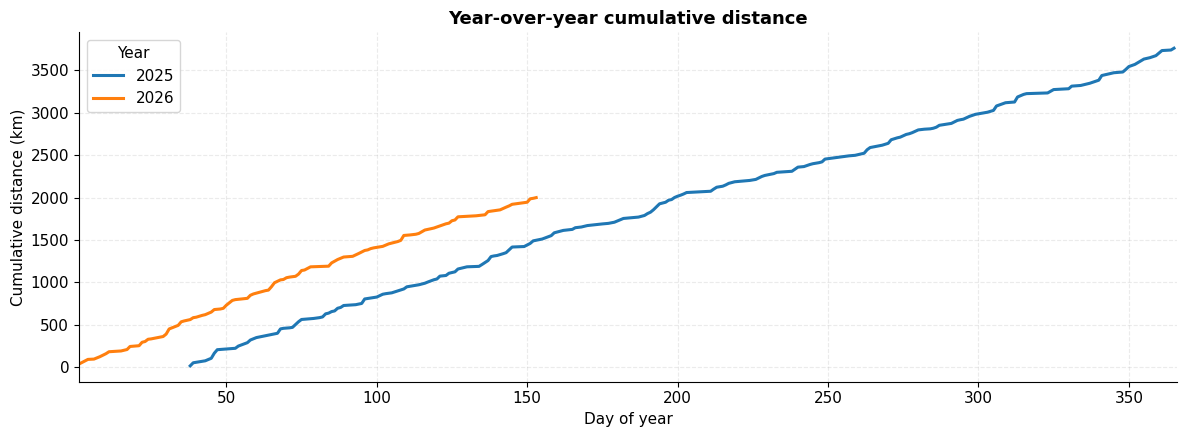

In [7]:
# --- Year-over-year cumulative distance ---
fig, ax = plt.subplots(figsize=(12, 4.5))
for year, g in df.groupby("year"):
    g = g.sort_values("day_of_year")
    ax.plot(g["day_of_year"], g["distance_km"].cumsum(), lw=2.2, label=str(year))
ax.set_xlabel("Day of year"); ax.set_ylabel("Cumulative distance (km)")
ax.set_title("Year-over-year cumulative distance"); ax.legend(title="Year")
ax.set_xlim(1, 366)
plt.tight_layout(); plt.show()

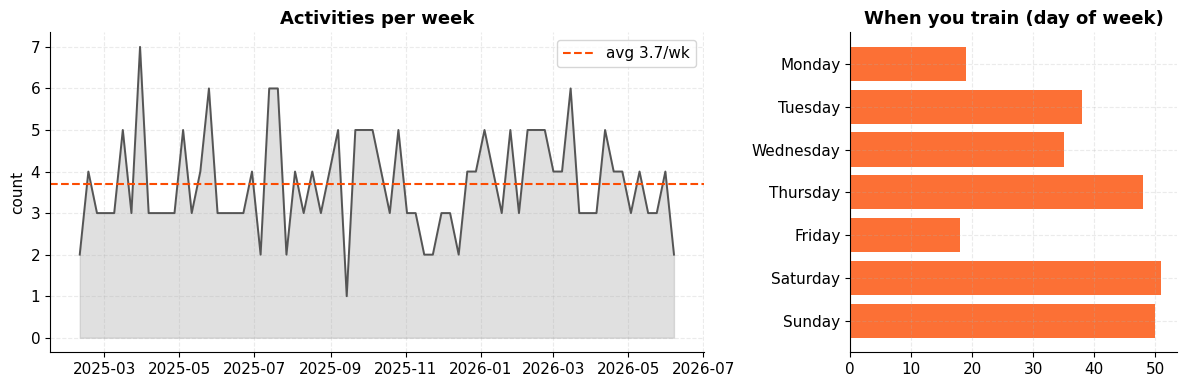

In [8]:
# --- Consistency: weekly activity count + day-of-week pattern ---
weekly_n = ts["id"].resample("W").count()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(weekly_n.index, weekly_n.values, color="#555", lw=1.4)
axes[0].fill_between(weekly_n.index, weekly_n.values, color="#999", alpha=0.3)
axes[0].axhline(weekly_n.mean(), color=STRAVA_ORANGE, ls="--", label=f"avg {weekly_n.mean():.1f}/wk")
axes[0].set_title("Activities per week"); axes[0].set_ylabel("count"); axes[0].legend()

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = df.groupby("dow_name")["id"].count().reindex(order).fillna(0)
axes[1].barh(dow.index, dow.values, color=STRAVA_ORANGE, alpha=0.8)
axes[1].invert_yaxis(); axes[1].set_title("When you train (day of week)")
plt.tight_layout(); plt.show()

## 6. Performance & efforts
Speed/pace distributions, heart-rate zones, aerobic efficiency, and training load.

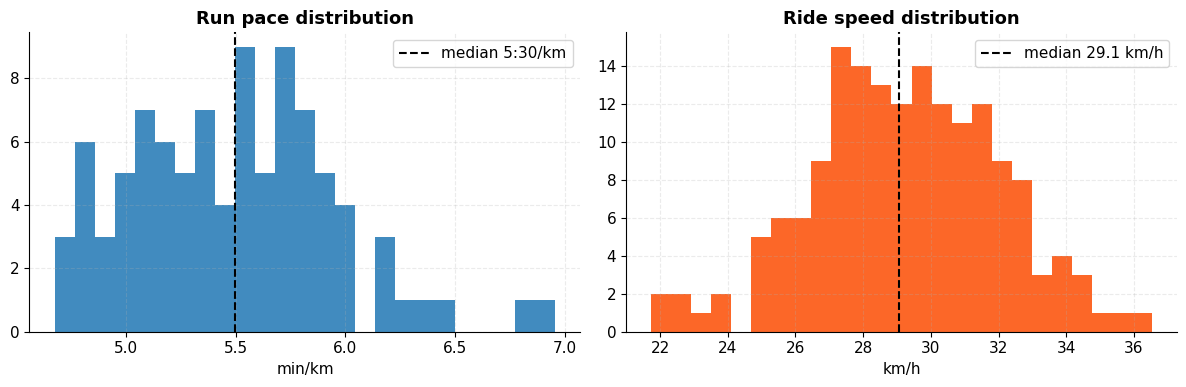

In [9]:
# --- Pace distribution (runs) and speed distribution (rides) ---
runs = df[df["type"] == "Run"]; rides = df[df["type"] == "Ride"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not runs.empty:
    axes[0].hist(runs["pace_min_km"].dropna(), bins=25, color=COLORS["Run"], alpha=0.85)
    med = runs["pace_min_km"].median()
    axes[0].axvline(med, color="black", ls="--", label=f"median {fmt_pace(med)}")
    axes[0].set_title("Run pace distribution"); axes[0].set_xlabel("min/km"); axes[0].legend()
if not rides.empty:
    axes[1].hist(rides["speed_kmh"].dropna(), bins=25, color=STRAVA_ORANGE, alpha=0.85)
    med = rides["speed_kmh"].median()
    axes[1].axvline(med, color="black", ls="--", label=f"median {med:.1f} km/h")
    axes[1].set_title("Ride speed distribution"); axes[1].set_xlabel("km/h"); axes[1].legend()
plt.tight_layout(); plt.show()

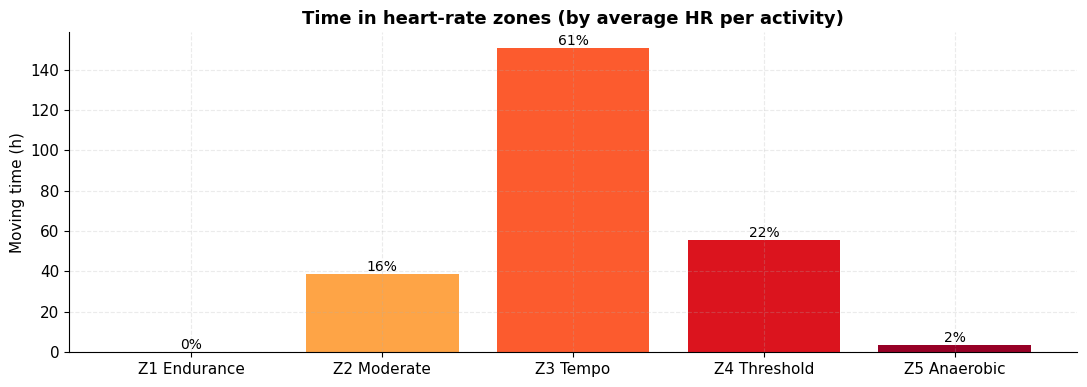

In [10]:
# --- Heart-rate zone distribution (time per zone, by average HR) ---
hr_zones = client.fetch_zones()  # fetched once here, reused in §7
zones = hr_zones
if zones:
    edges, labels = [], []
    for z in zones:
        lo = z.get("min", 0); hi = z.get("max", -1)
        edges.append(lo)
        labels.append(z.get("name", f"Z{len(labels)+1}"))
    edges.append(10_000)  # open-ended top zone
    edges = [e if e >= 0 else edges[i-1] for i, e in enumerate(edges)]
    cats = pd.cut(df["average_hr"], bins=edges, labels=labels, right=False, include_lowest=True)
    zone_hours = df.groupby(cats, observed=False)["moving_hours"].sum().reindex(labels).fillna(0)

    cmap = plt.cm.YlOrRd(np.linspace(0.25, 0.95, len(labels)))
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(zone_hours.index, zone_hours.values, color=cmap)
    pct = 100 * zone_hours / zone_hours.sum()
    for i, (h, p) in enumerate(zip(zone_hours.values, pct.values)):
        ax.text(i, h, f"{p:.0f}%", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Moving time (h)")
    ax.set_title("Time in heart-rate zones (by average HR per activity)")
    plt.tight_layout(); plt.show()
else:
    print("This server does not expose HR zones.")

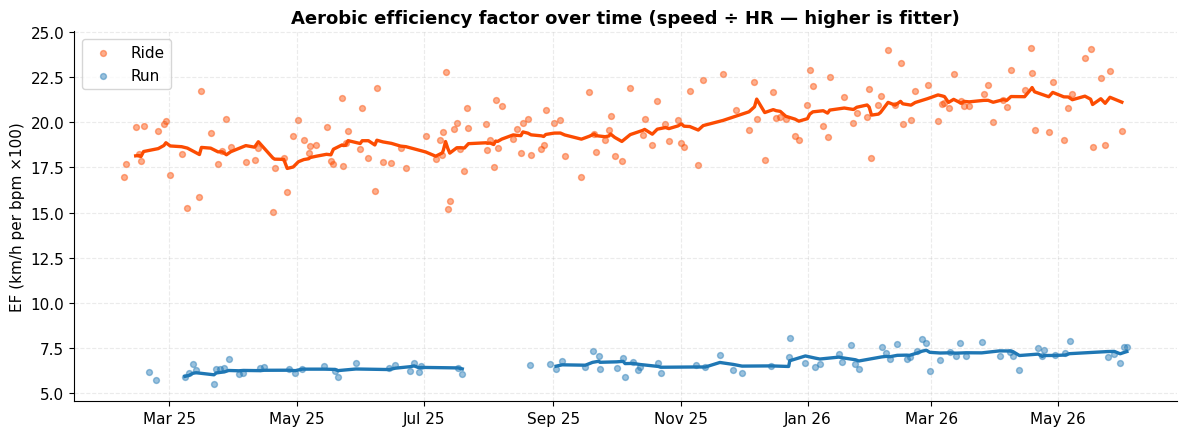

In [11]:
# --- Aerobic efficiency over time (distance covered per heartbeat-effort) ---
# Efficiency Factor: speed per unit HR. Rising EF over time = improving aerobic fitness.
eff = df.dropna(subset=["average_hr", "speed_kmh"]).copy()
eff = eff[eff["average_hr"] > 0]
eff["EF"] = eff["speed_kmh"] / eff["average_hr"] * 100  # scaled for readability

fig, ax = plt.subplots(figsize=(12, 4.5))
for t, g in eff.groupby("type"):
    ax.scatter(g["start_date"], g["EF"], s=18, alpha=0.45, color=color_for(t), label=t)
    roll = g.set_index("start_date")["EF"].sort_index().rolling("28D", min_periods=3).mean()
    ax.plot(roll.index, roll.values, color=color_for(t), lw=2.4)
ax.set_title("Aerobic efficiency factor over time (speed ÷ HR — higher is fitter)")
ax.set_ylabel("EF (km/h per bpm ×100)"); ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.tight_layout(); plt.show()

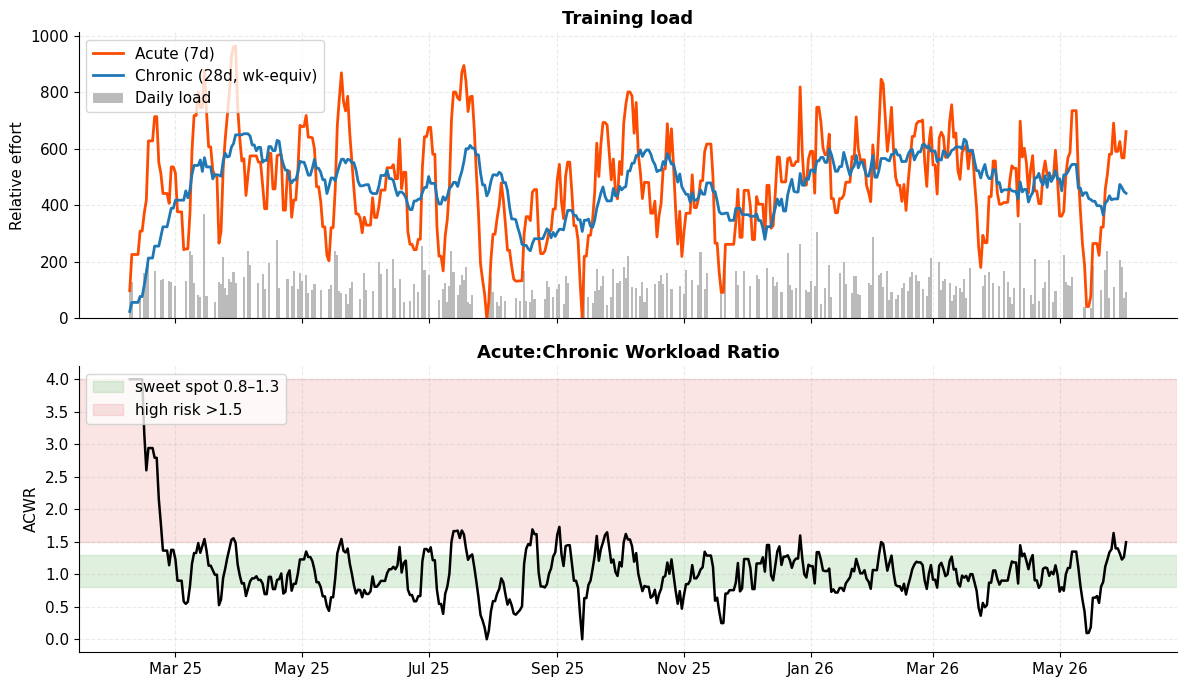

Most recent ACWR: 1.49  (building / tapering)


In [12]:
# --- Training load & injury-risk (Acute:Chronic Workload Ratio) ---
# Daily load proxy = relative effort / suffer score, including rest days as 0.
daily_load = ts["suffer_score"].resample("D").sum().fillna(0)
acute = daily_load.rolling(7, min_periods=1).sum()                  # ~1 week fatigue
chronic = daily_load.rolling(28, min_periods=1).sum() * (7 / 28)    # ~4 week fitness (weekly-equiv)
acwr = (acute / chronic.replace(0, np.nan))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(daily_load.index, daily_load.values, width=1, color="#bbb", label="Daily load")
axes[0].plot(acute.index, acute.values, color=STRAVA_ORANGE, lw=2, label="Acute (7d)")
axes[0].plot(chronic.index, chronic.values, color="#1f77b4", lw=2, label="Chronic (28d, wk-equiv)")
axes[0].set_ylabel("Relative effort"); axes[0].set_title("Training load"); axes[0].legend(loc="upper left")

axes[1].axhspan(0.8, 1.3, color="#2ca02c", alpha=0.15, label="sweet spot 0.8–1.3")
axes[1].axhspan(1.5, acwr.max(skipna=True) if acwr.notna().any() else 2, color="#d62728", alpha=0.12, label="high risk >1.5")
axes[1].plot(acwr.index, acwr.values, color="black", lw=1.8)
axes[1].set_ylabel("ACWR"); axes[1].set_title("Acute:Chronic Workload Ratio"); axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
plt.tight_layout(); plt.show()

latest_acwr = acwr.dropna().iloc[-1] if acwr.notna().any() else float("nan")
print(f"Most recent ACWR: {latest_acwr:.2f}  "
      f"({'⚠️ high — ease off' if latest_acwr > 1.5 else '✅ in the sweet spot' if 0.8 <= latest_acwr <= 1.3 else 'building / tapering'})")

In [13]:
# --- Personal bests & top efforts ---
def top(frame, col, n=1, ascending=False, min_km=0):
    f = frame[frame["distance_km"] >= min_km].dropna(subset=[col])
    return f.sort_values(col, ascending=ascending).head(n)

records = []
def add(label, row, value):
    if len(row):
        r = row.iloc[0]
        records.append({"Record": label, "Value": value(r),
                        "Activity": r["name"], "Date": str(r["date"])})

add("Longest ride", top(rides, "distance_km"), lambda r: f"{r['distance_km']:.1f} km")
add("Longest run", top(runs, "distance_km"), lambda r: f"{r['distance_km']:.1f} km")
add("Fastest ride (≥20 km)", top(rides, "speed_kmh", min_km=20), lambda r: f"{r['speed_kmh']:.1f} km/h")
add("Fastest run (≥5 km)", top(runs, "pace_min_km", ascending=True, min_km=5), lambda r: fmt_pace(r["pace_min_km"]))
add("Most elevation", top(df, "elevation_gain_m"), lambda r: f"{r['elevation_gain_m']:.0f} m")
add("Hardest effort", top(df, "suffer_score"), lambda r: f"{r['suffer_score']:.0f} RE")
add("Highest avg power", top(rides, "average_watts"), lambda r: f"{r['average_watts']:.0f} W")

records_df = pd.DataFrame(records)
print("🏅 Personal bests")
records_df

🏅 Personal bests


,Record,Value,Activity,Date
0,Longest ride,66.2 km,Club Ride,2025-03-15
1,Longest run,18.4 km,Morning Run,2026-01-04
2,Fastest ride (≥20 km),35.5 km/h,Lunch Ride,2026-05-21
3,Fastest run (≥5 km),4:40/km,Easy Run,2026-03-25
4,Most elevation,932 m,Club Ride,2026-05-03
5,Hardest effort,369 RE,Club Ride,2025-03-15
6,Highest avg power,246 W,Club Ride,2026-04-06


## 7. Drill into a single activity
Fetch the per-second **streams** (heart rate, speed, altitude) for one activity and compute true
time-in-zone. Here we pick your longest activity.

Activity #15000000043: Club Ride — 66.2 km on 2025-03-15


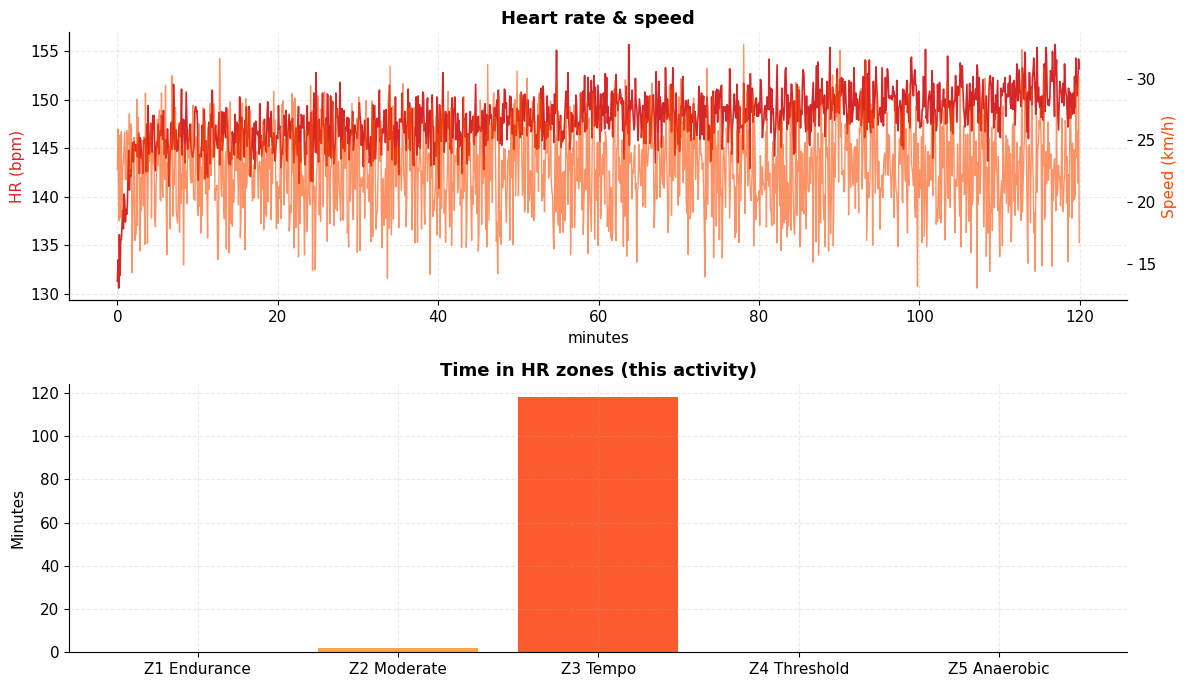

In [14]:
target = df.sort_values("distance_km").iloc[-1]
sid = int(target["id"])
print(f"Activity #{sid}: {target['name']} — {target['distance_km']:.1f} km on {target['date']}")

streams = client.fetch_streams(sid)
if streams.empty or "heartrate" not in streams.columns:
    print("No heart-rate streams available for this activity / server.")
else:
    streams = streams.copy()
    # Some servers omit a time stream; fall back to a sample index.
    if "time" in streams.columns:
        streams["x"] = streams["time"] / 60.0
        x_label = "minutes"
        dt = streams["time"].diff().median()
        dt = dt if (pd.notna(dt) and dt > 0) else None
    else:
        streams["x"] = np.arange(len(streams))
        x_label = "sample"
        dt = None
    if "velocity_smooth" in streams.columns:
        streams["speed_kmh"] = streams["velocity_smooth"] * 3.6

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    axes[0].plot(streams["x"], streams["heartrate"], color="#d62728", lw=1.2)
    axes[0].set_ylabel("HR (bpm)", color="#d62728"); axes[0].set_xlabel(x_label)
    axes[0].set_title("Heart rate & speed")
    if "speed_kmh" in streams.columns:
        axt = axes[0].twinx()
        axt.plot(streams["x"], streams["speed_kmh"], color=STRAVA_ORANGE, lw=1, alpha=0.6)
        axt.set_ylabel("Speed (km/h)", color=STRAVA_ORANGE); axt.grid(False)

    # Time-in-zone from the HR stream (true minutes if dt known, else % of samples).
    if hr_zones:
        edges = [z.get("min", 0) for z in hr_zones] + [10_000]
        edges = [e if e >= 0 else edges[i - 1] for i, e in enumerate(edges)]
        labels = [z.get("name", f"Z{i+1}") for i, z in enumerate(hr_zones)]
        cats = pd.cut(streams["heartrate"], bins=edges, labels=labels, right=False, include_lowest=True)
        counts = cats.value_counts().reindex(labels).fillna(0)
        if dt:
            values, ylabel = counts * dt / 60.0, "Minutes"
        else:
            values, ylabel = 100 * counts / counts.sum(), "% of samples"
        cmap = plt.cm.YlOrRd(np.linspace(0.25, 0.95, len(labels)))
        axes[1].bar(values.index, values.values, color=cmap)
        axes[1].set_ylabel(ylabel); axes[1].set_title("Time in HR zones (this activity)")
    else:
        fig.delaxes(axes[1])
    plt.tight_layout(); plt.show()

## 8. Key takeaways
Auto-generated summary from the numbers above.

In [15]:
last4 = weekly_km.tail(4).mean()
prev4 = weekly_km.tail(8).head(4).mean()
trend = "up 📈" if last4 > prev4 * 1.05 else "down 📉" if last4 < prev4 * 0.95 else "steady ➡️"
busiest_month = monthly["distance_km"].idxmax()

print("📋 SUMMARY")
print("-" * 48)
print(f"• {len(df)} activities over {weeks:.0f} weeks "
      f"({df['distance_km'].sum():,.0f} km, {fmt_hms(df['moving_time_s'].sum())}, "
      f"{df['elevation_gain_m'].sum():,.0f} m climbed).")
print(f"• Recent form: last 4 wks avg {last4:.0f} km/wk vs prior {prev4:.0f} km/wk — {trend}")
print(f"• Busiest month: {busiest_month:%B %Y} ({monthly['distance_km'].max():.0f} km).")
if not runs.empty:
    print(f"• Median run pace {fmt_pace(runs['pace_min_km'].median())}; "
          f"best {fmt_pace(runs[runs['distance_km']>=5]['pace_min_km'].min())} (≥5 km).")
if not rides.empty:
    print(f"• Median ride speed {rides['speed_kmh'].median():.1f} km/h; "
          f"longest {rides['distance_km'].max():.0f} km.")
print(f"• Current training-load status (ACWR {latest_acwr:.2f}): "
      f"{'ease off — injury risk' if latest_acwr > 1.5 else 'optimal load' if 0.8 <= latest_acwr <= 1.3 else 'ramping or tapering'}.")
print("-" * 48)
print("Tip: set STRAVA_MCP_COMMAND + your Strava credentials (see §2) to run this on your own data.")

📋 SUMMARY
------------------------------------------------
• 259 activities over 69 weeks (5,761 km, 249h 05m, 59,787 m climbed).
• Recent form: last 4 wks avg 57 km/wk vs prior 87 km/wk — down 📉
• Busiest month: January 2026 (452 km).
• Median run pace 5:30/km; best 4:40/km (≥5 km).
• Median ride speed 29.1 km/h; longest 66 km.
• Current training-load status (ACWR 1.49): ramping or tapering.
------------------------------------------------
Tip: set STRAVA_MCP_COMMAND + your Strava credentials (see §2) to run this on your own data.
